# Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
from sklearn.metrics import mean_absolute_error,mean_squared_error, r2_score
from sklearn.ensemble import BaggingClassifier, BaggingRegressor
from sklearn.ensemble import AdaBoostClassifier, AdaBoostRegressor
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from xgboost import XGBClassifier, XGBRegressor
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import StackingClassifier, StackingRegressor

import warnings
warnings.filterwarnings("ignore")

# Load Dataset

In [4]:
df = pd.read_csv("Smart_Outcome_Predictor_Dataset_5200.csv")
df.head()

,student_id,age,country_region,device_type,education_background,course_level,course_category,course_start_date,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,completion_status,final_score
0,700001,32,Europe,Laptop,Undergrad,Intermediate,Business,2024-03-18,12,1,7.6,1,6,1,1,53.3,0.655,0,49.8
1,700002,17,Europe,Laptop,Undergrad,Intermediate,Programming,2024-08-22,34,16,27.2,6,4,7,1,51.5,1.000,1,84.0
2,700003,25,Europe,Mobile,Graduate,Advanced,Programming,2024-09-28,39,6,7.1,16,2,2,0,62.2,0.810,0,62.5
3,700004,26,Asia,Mobile,Undergrad,Beginner,Design,2024-03-09,10,34,22.1,57,9,6,0,59.3,0.875,1,89.5
4,700005,26,Asia,Tablet,WorkingPro,Advanced,Business,2024-03-21,12,22,32.3,41,9,2,0,65.1,0.814,0,67.4


In [5]:
df.shape

(5200, 19)

# Data Overview

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             5200 non-null   int64  
 1   age                    5200 non-null   int64  
 2   country_region         5200 non-null   object 
 3   device_type            5200 non-null   object 
 4   education_background   5200 non-null   object 
 5   course_level           5200 non-null   object 
 6   course_category        5200 non-null   object 
 7   course_start_date      5200 non-null   object 
 8   week_of_year           5200 non-null   int64  
 9   sessions               5200 non-null   int64  
 10  time_spent_hours       5088 non-null   float64
 11  videos_watched         5200 non-null   int64  
 12  quiz_attempts          5200 non-null   int64  
 13  assignments_submitted  5200 non-null   int64  
 14  forum_posts            5200 non-null   int64  
 15  avg_

In [8]:
df.describe().round(3)

,student_id,age,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,completion_status,final_score
count,5200.000,5200.000,5200.000,5200.000,5088.000,5200.000,5200.000,5200.000,5200.000,5119.000,5120.000,5200.000,5200.000
mean,702600.500,24.340,26.622,19.122,18.216,25.853,6.996,3.836,1.586,66.843,0.847,0.375,74.822
std,1501.255,5.579,15.008,10.727,10.734,17.720,2.568,1.952,1.271,13.814,0.114,0.484,13.532
min,700001.000,16.000,1.000,1.000,0.600,0.000,0.000,0.000,0.000,0.000,0.313,0.000,35.200
25%,701300.750,20.000,14.000,11.000,10.300,13.000,5.000,2.000,1.000,57.500,0.769,0.000,64.700
50%,702600.500,24.000,27.000,17.000,16.100,23.000,7.000,4.000,1.000,66.900,0.855,0.000,74.100
75%,703900.250,28.000,40.000,25.000,23.800,35.000,9.000,5.000,2.000,76.200,0.942,1.000,84.900
max,705200.000,45.000,52.000,94.000,76.800,158.000,20.000,12.000,8.000,100.000,1.000,1.000,100.000


In [9]:
df.isnull().sum()

student_id                 0
age                        0
country_region             0
device_type                0
education_background       0
course_level               0
course_category            0
course_start_date          0
week_of_year               0
sessions                   0
time_spent_hours         112
videos_watched             0
quiz_attempts              0
assignments_submitted      0
forum_posts                0
avg_quiz_score            81
attendance_rate           80
completion_status          0
final_score                0
dtype: int64

In [10]:
df.duplicated().sum()

0

# Exploratory Data Analysis (EDA)

In [12]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

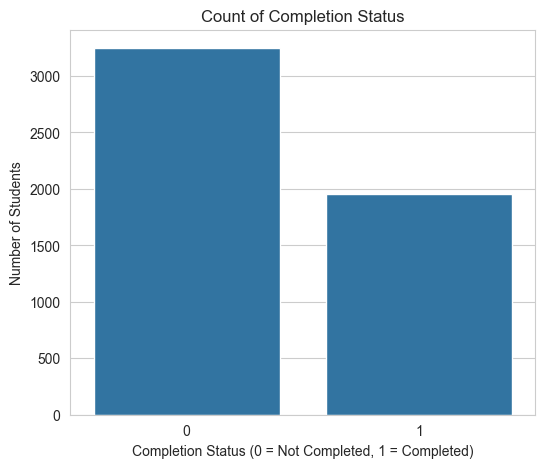

In [13]:
plt.figure(figsize=(6,5))
sns.countplot(x="completion_status", data=df)
plt.title("Count of Completion Status")
plt.xlabel("Completion Status (0 = Not Completed, 1 = Completed)")
plt.ylabel("Number of Students")
plt.savefig("countplot_completion_status.png", dpi=300, bbox_inches="tight")
plt.show()

**Conclusion:**

- More students did not complete the course compared to students who completed it.
- The dataset is slightly imbalanced towards non completion.

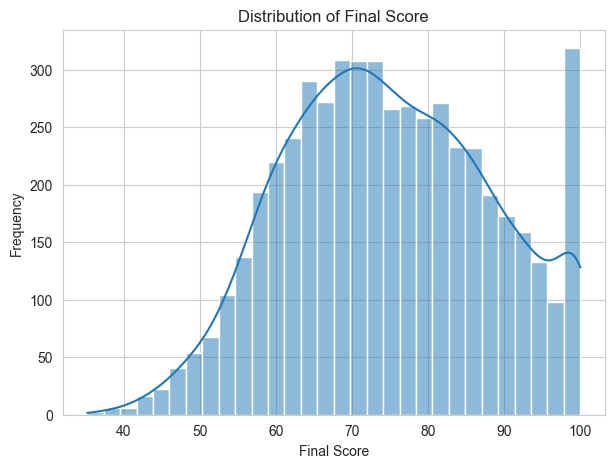

In [15]:
plt.figure(figsize=(7,5))
sns.histplot(df["final_score"], bins=30, kde=True)
plt.title("Distribution of Final Score")
plt.xlabel("Final Score")
plt.ylabel("Frequency")
plt.savefig("histogram_final_score.png", dpi=300, bbox_inches="tight")
plt.show()

**Conclusion:**

- Most students score between 60 and 90.
- Very few students score below 45 or above 95.

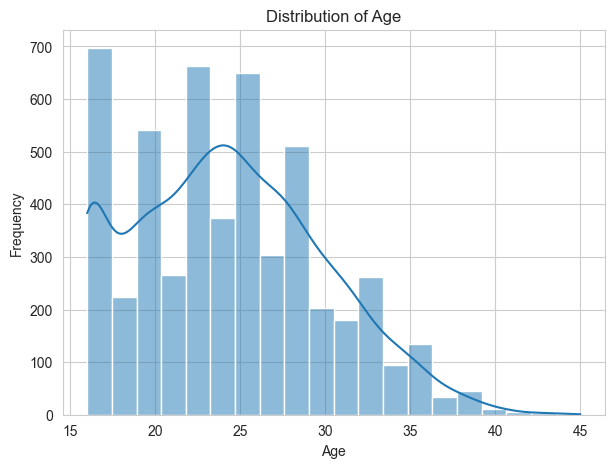

In [17]:
plt.figure(figsize=(7,5))
sns.histplot(df["age"], bins=20, kde=True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.savefig("histogram_age.png", dpi=300, bbox_inches="tight")
plt.show()

**Conclusion:**

- Most students are between 18 and 30 years old.
- Very few students are above 35 years.

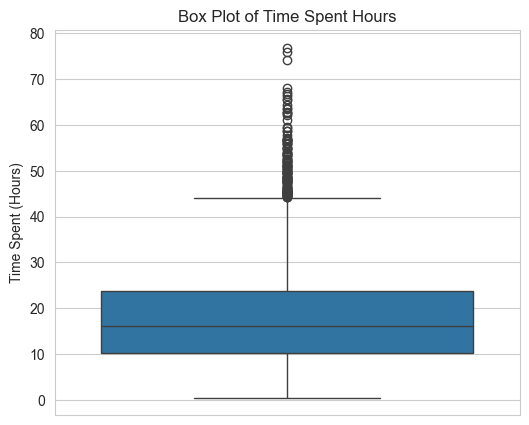

In [19]:
plt.figure(figsize=(6,5))
sns.boxplot(y=df["time_spent_hours"])
plt.title("Box Plot of Time Spent Hours")
plt.ylabel("Time Spent (Hours)")
plt.savefig("boxplot_time_spent_hours.png", dpi=300, bbox_inches="tight")
plt.show()

**Conclusion:**

- Most students spend between 5 and 30 hours on the course.
- A few students show very high time spent, which can be considered as outliers.

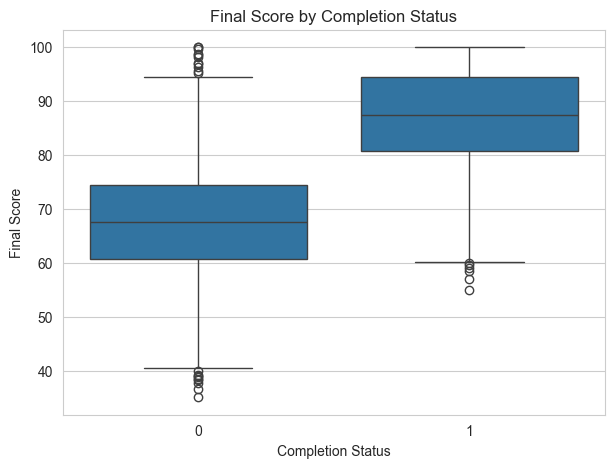

In [21]:
plt.figure(figsize=(7,5))
sns.boxplot(x="completion_status", y="final_score", data=df)
plt.title("Final Score by Completion Status")
plt.xlabel("Completion Status")
plt.ylabel("Final Score")
plt.savefig("boxplot_score_by_completion.png", dpi=300, bbox_inches="tight")
plt.show()

**Conclusion:**

- Students who completed the course generally have higher final scores.
- Students who did not complete the course have a wider spread of lower scores.

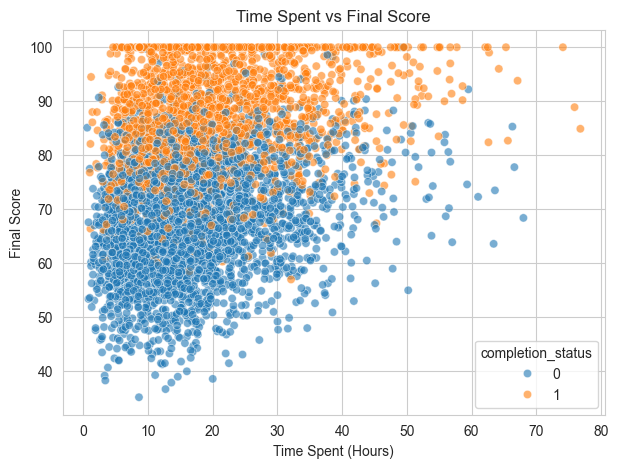

In [23]:
plt.figure(figsize=(7,5))
sns.scatterplot(x="time_spent_hours", y="final_score", hue="completion_status", data=df, alpha=0.6)
plt.title("Time Spent vs Final Score")
plt.xlabel("Time Spent (Hours)")
plt.ylabel("Final Score")
plt.savefig("scatter_time_vs_score.png", dpi=300, bbox_inches="tight")
plt.show()

**Conclusion:**

- Students who spend more time on the course tend to score higher.
- Students who completed the course are mostly clustered at higher time spent and higher scores.

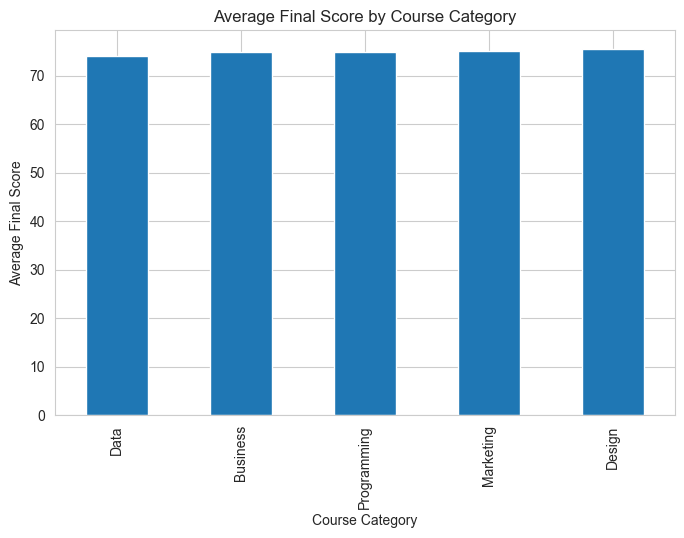

In [25]:
plt.figure(figsize=(8,5))
df.groupby("course_category")["final_score"].mean().sort_values().plot(kind="bar")
plt.title("Average Final Score by Course Category")
plt.xlabel("Course Category")
plt.ylabel("Average Final Score")
plt.savefig("barplot_score_by_category.png", dpi=300, bbox_inches="tight")
plt.show()

**Conclusion:**

- Average final score is fairly similar across course categories.
- Some categories show slightly higher average performance than others.

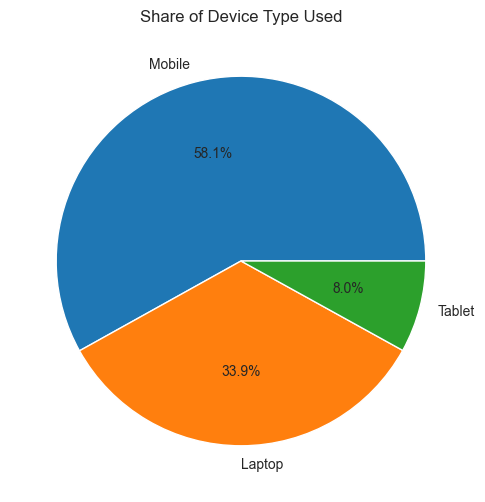

In [27]:
plt.figure(figsize=(6,6))
df["device_type"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Share of Device Type Used")
plt.ylabel("")
plt.savefig("piechart_device_type.png", dpi=300, bbox_inches="tight")
plt.show()

**Conclusion:**

- Most students access the course using a Laptop.
- Mobile and Tablet are used by a smaller portion of students.

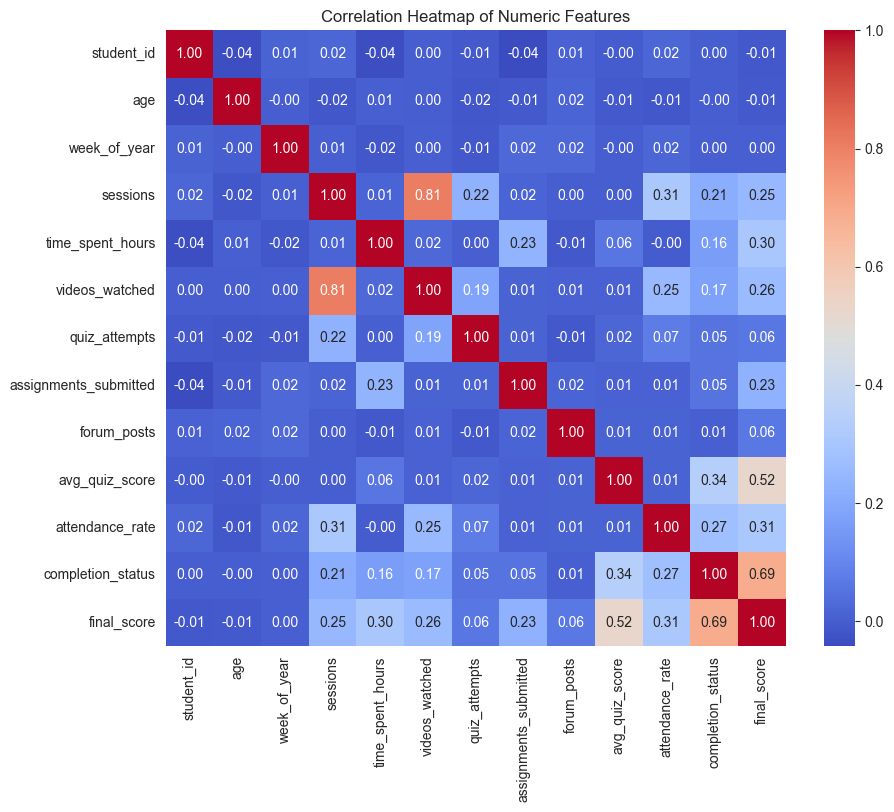

In [29]:
plt.figure(figsize=(10,8))
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Numeric Features")
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

**Conclusion:**

- avg_quiz_score and attendance_rate show a positive correlation with final_score.
- time_spent_hours and sessions also show a positive relationship with final_score and completion_status.

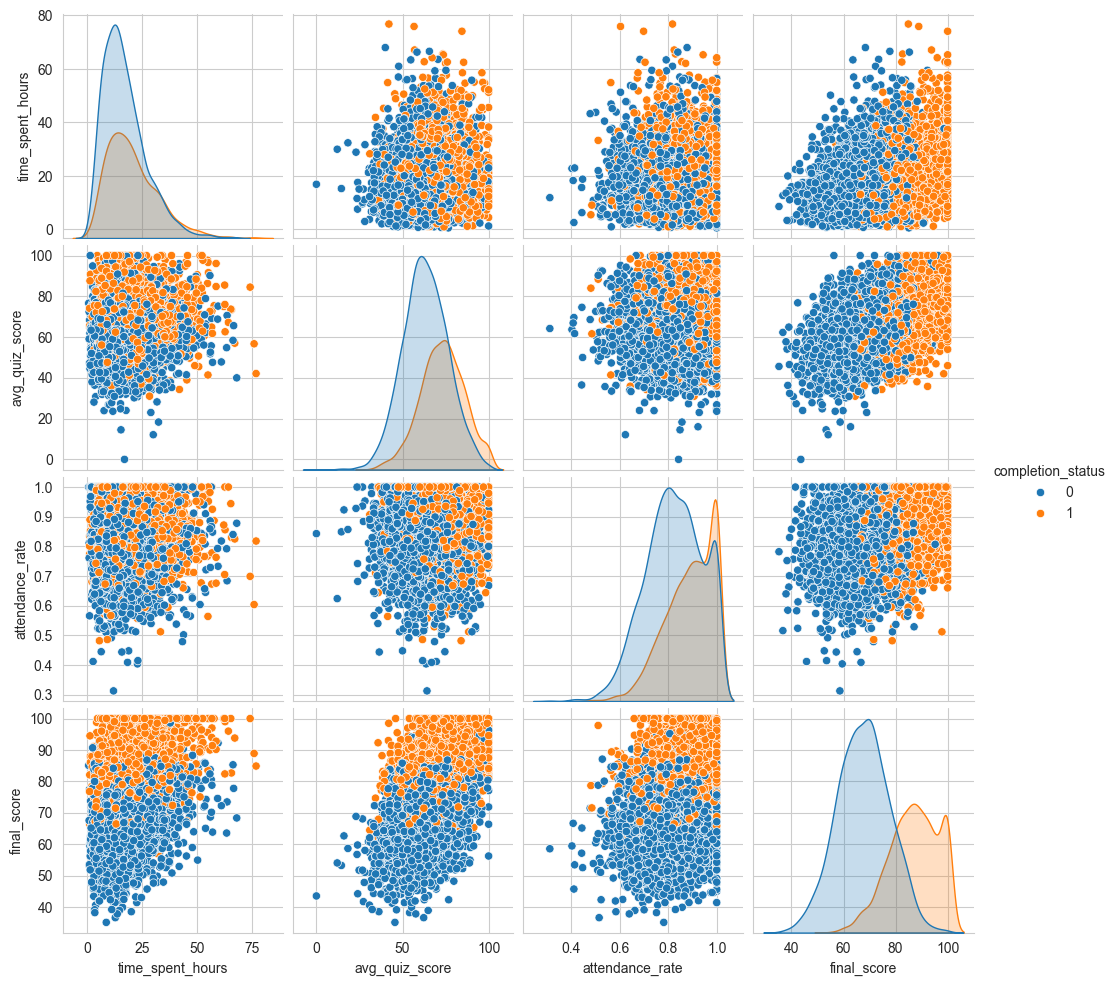

In [31]:
sns.pairplot(df[["time_spent_hours", "avg_quiz_score", "attendance_rate", "final_score", "completion_status"]], hue="completion_status")
plt.savefig("pairplot_key_features.png", dpi=300, bbox_inches="tight")
plt.show()

**Conclusion:**

- Students with higher avg_quiz_score and attendance_rate generally complete the course and score higher.
- The two completion status groups are reasonably separable based on these features.

# Data Cleaning

In [34]:
missing_cols = ["time_spent_hours", "avg_quiz_score", "attendance_rate"]

imputer = SimpleImputer(strategy="median")
df[missing_cols] = imputer.fit_transform(df[missing_cols])

df.isnull().sum()

student_id               0
age                      0
country_region           0
device_type              0
education_background     0
course_level             0
course_category          0
course_start_date        0
week_of_year             0
sessions                 0
time_spent_hours         0
videos_watched           0
quiz_attempts            0
assignments_submitted    0
forum_posts              0
avg_quiz_score           0
attendance_rate          0
completion_status        0
final_score              0
dtype: int64

In [35]:
Q1 = df["time_spent_hours"].quantile(0.25)
Q3 = df["time_spent_hours"].quantile(0.75)
IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[(df["time_spent_hours"] < lower_limit) | (df["time_spent_hours"] > upper_limit)]
print("Number of outliers in time_spent_hours:", outliers.shape[0])

Number of outliers in time_spent_hours: 149


**Observation:**

- A small number of outliers are present in time_spent_hours.
- Since the number of outliers is small and they represent genuine highly engaged students, we keep them in the dataset instead of removing them.

# Feature Engineering

In [38]:
df["course_start_date"] = pd.to_datetime(df["course_start_date"])
df["enrollment_month"] = df["course_start_date"].dt.month
df = df.drop(columns=["course_start_date"])
df.head()

,student_id,age,country_region,device_type,education_background,course_level,course_category,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,completion_status,final_score,enrollment_month
0,700001,32,Europe,Laptop,Undergrad,Intermediate,Business,12,1,7.6,1,6,1,1,53.3,0.655,0,49.8,3
1,700002,17,Europe,Laptop,Undergrad,Intermediate,Programming,34,16,27.2,6,4,7,1,51.5,1.000,1,84.0,8
2,700003,25,Europe,Mobile,Graduate,Advanced,Programming,39,6,7.1,16,2,2,0,62.2,0.810,0,62.5,9
3,700004,26,Asia,Mobile,Undergrad,Beginner,Design,10,34,22.1,57,9,6,0,59.3,0.875,1,89.5,3
4,700005,26,Asia,Tablet,WorkingPro,Advanced,Business,12,22,32.3,41,9,2,0,65.1,0.814,0,67.4,3


In [39]:
categorical_cols = ["country_region", "device_type", "education_background", "course_level", "course_category"]

df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df_encoded.head()

,student_id,age,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,...,device_type_Tablet,education_background_HighSchool,education_background_Undergrad,education_background_WorkingPro,course_level_Beginner,course_level_Intermediate,course_category_Data,course_category_Design,course_category_Marketing,course_category_Programming
0,700001,32,12,1,7.6,1,6,1,1,53.3,...,False,False,True,False,False,True,False,False,False,False
1,700002,17,34,16,27.2,6,4,7,1,51.5,...,False,False,True,False,False,True,False,False,False,True
2,700003,25,39,6,7.1,16,2,2,0,62.2,...,False,False,False,False,False,False,False,False,False,True
3,700004,26,10,34,22.1,57,9,6,0,59.3,...,False,False,True,False,True,False,False,True,False,False
4,700005,26,12,22,32.3,41,9,2,0,65.1,...,True,False,False,True,False,False,False,False,False,False


In [40]:
numeric_cols = ["age", "week_of_year", "sessions", "time_spent_hours", "videos_watched",
                 "quiz_attempts", "assignments_submitted", "forum_posts", "avg_quiz_score",
                 "attendance_rate", "enrollment_month"]

scaler = StandardScaler()
df_encoded[numeric_cols] = scaler.fit_transform(df_encoded[numeric_cols])

df_encoded.head()

,student_id,age,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,...,device_type_Tablet,education_background_HighSchool,education_background_Undergrad,education_background_WorkingPro,course_level_Beginner,course_level_Intermediate,course_category_Data,course_category_Design,course_category_Marketing,course_category_Programming
0,700001,1.373240,-0.974361,-1.689583,-0.995226,-1.402629,-0.387795,-1.453038,-0.460896,-0.988243,...,False,False,True,False,False,True,False,False,False,False
1,700002,-1.315738,0.491691,-0.291070,0.850125,-1.120443,-1.166681,1.621340,-0.460896,-1.119585,...,False,False,True,False,False,True,False,False,False,True
2,700003,0.118384,0.824885,-1.223412,-1.042301,-0.556070,-1.945567,-0.940642,-1.247977,-0.338828,...,False,False,False,False,False,False,False,False,False,True
3,700004,0.297649,-1.107638,1.387146,0.369957,1.757858,0.780534,1.108944,-1.247977,-0.550435,...,False,False,True,False,True,False,False,True,False,False
4,700005,0.297649,-0.974361,0.268335,1.330293,0.854862,0.780534,-0.940642,-1.247977,-0.127221,...,True,False,False,True,False,False,False,False,False,False


# Train-Test Split 

In [42]:
X = df_encoded.drop(columns=["completion_status", "final_score","student_id"])
y_class = df_encoded["completion_status"]  # For classification
y_reg = df_encoded["final_score"]   # for regression

In [43]:
# for classifiction
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_class, test_size=0.2, random_state=42, stratify=y_class)

In [44]:
# for regression
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y_reg, test_size=0.2, random_state=42)

# Model Building

In [46]:
# single decision tree classifier
base_clf = DecisionTreeClassifier(random_state=42) 
base_clf.fit(X_train_c, y_train_c)
base_clf_pred = base_clf.predict(X_test_c)
accuracy_score(y_test_c, base_clf_pred)

0.6336538461538461

In [47]:
# single decision tree regressor
base_reg = DecisionTreeRegressor(random_state=42)
base_reg.fit(X_train_r, y_train_r)
base_reg_pred = base_reg.predict(X_test_r)
r2_score(y_test_r, base_reg_pred)

-0.08675369742922756

In [48]:
# Bagging
# calssification
bagging_clf = BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42), n_estimators=100, random_state=42)
bagging_clf.fit(X_train_c, y_train_c)
bagging_clf_pred = bagging_clf.predict(X_test_c)
bagging_clf_proba = bagging_clf.predict_proba(X_test_c)[:, 1]
accuracy_score(y_test_c, bagging_clf_pred)

0.7086538461538462

In [49]:
# regression
bagging_reg = BaggingRegressor(estimator=DecisionTreeRegressor(random_state=42), n_estimators=100, random_state=42)
bagging_reg.fit(X_train_r, y_train_r)
bagging_reg_pred = bagging_reg.predict(X_test_r)
r2_score(y_test_r, bagging_reg_pred)

0.4646082960119229

**Comparison of Bagging with Single Base Model:**
- The Bagging Classifier and Bagging Regressor perform better than the single Decision Tree model because Bagging trains many trees on different random samples and averages their predictions, which reduces variance and makes the model more stable.

In [51]:
# Bossting 
# AdaBoost Classifier
ada_clf = AdaBoostClassifier(n_estimators=100, random_state=42)
ada_clf.fit(X_train_c, y_train_c)
ada_clf_pred = ada_clf.predict(X_test_c)
ada_clf_proba = ada_clf.predict_proba(X_test_c)[:, 1]
accuracy_score(y_test_c, ada_clf_pred)

0.7278846153846154

In [52]:
# AdaBoost Regressor
ada_reg = AdaBoostRegressor(n_estimators=100, random_state=42)
ada_reg.fit(X_train_r, y_train_r)
ada_reg_pred = ada_reg.predict(X_test_r)
r2_score(y_test_r, ada_reg_pred)

0.395829291255418

**Observation:**
- AdaBoost builds models sequentially, where each new model focuses more on the samples that were predicted incorrectly by the previous model. This way the weak learners improve step by step and the final combined model becomes stronger.

In [54]:
# Gradient Boosting Classifier
gb_clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gb_clf.fit(X_train_c, y_train_c)
gb_clf_pred = gb_clf.predict(X_test_c)
gb_clf_proba = gb_clf.predict_proba(X_test_c)[:, 1]
accuracy_score(y_test_c, gb_clf_pred)

0.7346153846153847

In [55]:
# Gradient Boosting Regressor
gb_reg = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gb_reg.fit(X_train_r, y_train_r)
gb_reg_pred = gb_reg.predict(X_test_r)
r2_score(y_test_r, gb_reg_pred)

0.48658319136649997

**Effect of Learning Rate and Number of Estimators:**
- A smaller learning rate needs more estimators (trees) to reach good performance but usually gives smoother and more stable results. A larger learning rate learns faster but can overfit if the number of estimators is too high. Here we used a moderate learning rate of 0.1 with 100 estimators to balance speed and performance.

In [57]:
# LightGBM Classifier
lgbm_clf = LGBMClassifier(n_estimators=100, learning_rate=0.1, random_state=42, verbose=-1)
lgbm_clf.fit(X_train_c, y_train_c)
lgbm_clf_pred = lgbm_clf.predict(X_test_c)
lgbm_clf_proba = lgbm_clf.predict_proba(X_test_c)[:, 1]
accuracy_score(y_test_c, lgbm_clf_pred)

0.7240384615384615

In [58]:
# LightGBM Regressor
lgbm_reg = LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42, verbose=-1)
lgbm_reg.fit(X_train_r, y_train_r)
lgbm_reg_pred = lgbm_reg.predict(X_test_r)
r2_score(y_test_r, lgbm_reg_pred)

0.4678405912386233

**Observation:**
- LightGBM grows trees leaf-wise instead of level-wise and uses histogram based splitting, which makes it train faster than traditional Gradient Boosting while still giving competitive accuracy.

In [60]:
# XGBoost Classifier
xgb_clf = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42, eval_metric="logloss")
xgb_clf.fit(X_train_c, y_train_c)
xgb_clf_pred = xgb_clf.predict(X_test_c)
xgb_clf_proba = xgb_clf.predict_proba(X_test_c)[:, 1]
accuracy_score(y_test_c, xgb_clf_pred)

0.7201923076923077

In [61]:
# XGBoost Regressor
xgb_reg = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_reg.fit(X_train_r, y_train_r)
xgb_reg_pred = xgb_reg.predict(X_test_r)
r2_score(y_test_r, xgb_reg_pred)

0.4678404470820995

**Comparison of Boosting Algorithms:**
- AdaBoost is simple and works well on clean data but is sensitive to noisy data and outliers. Gradient Boosting generally gives better accuracy than AdaBoost but takes more time to train. LightGBM is the fastest among the boosting models due to its leaf-wise growth strategy. XGBoost usually gives the most robust and accurate results because of its built-in regularization that controls overfitting.

# Voting and Stacking Ensembles

In [64]:
log_reg = LogisticRegression(max_iter=1000)
tree_clf = DecisionTreeClassifier(random_state=42)
knn_clf_model = lgbm_clf

# Hard Voting
hard_voting_clf = VotingClassifier(estimators=[("lr", log_reg), ("dt", tree_clf), ("lgbm", LGBMClassifier(random_state=42, verbose=-1))], voting="hard")
hard_voting_clf.fit(X_train_c, y_train_c)
hard_voting_pred = hard_voting_clf.predict(X_test_c)
accuracy_score(y_test_c, hard_voting_pred)

0.7413461538461539

In [65]:
# Soft Voting
soft_voting_clf = VotingClassifier(estimators=[("lr", log_reg), ("dt", tree_clf), ("lgbm", LGBMClassifier(random_state=42, verbose=-1))], voting="soft")
soft_voting_clf.fit(X_train_c, y_train_c)
soft_voting_pred = soft_voting_clf.predict(X_test_c)
soft_voting_proba = soft_voting_clf.predict_proba(X_test_c)[:, 1]
accuracy_score(y_test_c, soft_voting_pred)

0.6942307692307692

**Hard Voting vs Soft Voting:**
- Hard Voting takes the majority class predicted by the base models. Soft Voting averages the predicted probabilities of the base models and then picks the class with the highest average probability. Soft Voting usually performs better because it uses more information (probabilities) instead of just the final class label.

In [67]:
# Stacking Classifier
stacking_clf = StackingClassifier(
    estimators=[("dt", DecisionTreeClassifier(random_state=42)),
                ("lgbm", LGBMClassifier(random_state=42, verbose=-1)),
                ("ada", AdaBoostClassifier(random_state=42))],
    final_estimator=LogisticRegression(max_iter=1000))
stacking_clf.fit(X_train_c, y_train_c)
stacking_clf_pred = stacking_clf.predict(X_test_c)
stacking_clf_proba = stacking_clf.predict_proba(X_test_c)[:, 1]
accuracy_score(y_test_c, stacking_clf_pred)

0.725

In [68]:
# Stacking Regressor
stacking_reg = StackingRegressor(
    estimators=[("dt", DecisionTreeRegressor(random_state=42)),
                ("lgbm", LGBMRegressor(random_state=42, verbose=-1)),
                ("ada", AdaBoostRegressor(random_state=42))],
    final_estimator=LinearRegression())
stacking_reg.fit(X_train_r, y_train_r)
stacking_reg_pred = stacking_reg.predict(X_test_r)
r2_score(y_test_r, stacking_reg_pred)

0.4770564930937158

**Advantages of Voting:**
- Voting combines different types of models that may capture different patterns in the data, which reduces the chance of a single model's mistake affecting the final prediction.

**Advantages of Stacking:**
- Stacking learns the best way to combine multiple base models using a meta-learner, instead of simply averaging or voting, which can give better performance than any individual base model.

# Model Evaluation - Classification

In [71]:
def evaluate_classifier(name, y_true, y_pred, y_proba):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba)
    }

classification_results = []
classification_results.append(evaluate_classifier("Bagging", y_test_c, bagging_clf_pred, bagging_clf_proba))
classification_results.append(evaluate_classifier("AdaBoost", y_test_c, ada_clf_pred, ada_clf_proba))
classification_results.append(evaluate_classifier("Gradient Boosting", y_test_c, gb_clf_pred, gb_clf_proba))
classification_results.append(evaluate_classifier("LightGBM", y_test_c, lgbm_clf_pred, lgbm_clf_proba))
classification_results.append(evaluate_classifier("XGBoost", y_test_c, xgb_clf_pred, xgb_clf_proba))
classification_results.append(evaluate_classifier("Soft Voting", y_test_c, soft_voting_pred, soft_voting_proba))
classification_results.append(evaluate_classifier("Stacking", y_test_c, stacking_clf_pred, stacking_clf_proba))

classification_results_df = pd.DataFrame(classification_results).sort_values(by="Accuracy", ascending=False)
classification_results_df.to_csv("classification_results.csv", index=False)
classification_results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Gradient Boosting,0.734615,0.667647,0.582051,0.621918,0.788142
1,AdaBoost,0.727885,0.663609,0.556410,0.605300,0.777874
6,Stacking,0.725000,0.671053,0.523077,0.587896,0.774154
3,LightGBM,0.724038,0.652819,0.564103,0.605227,0.773578
4,XGBoost,0.720192,0.641026,0.576923,0.607287,0.769633
0,Bagging,0.708654,0.629080,0.543590,0.583219,0.758454
5,Soft Voting,0.694231,0.600559,0.551282,0.574866,0.755160


Best Classification Model: Gradient Boosting


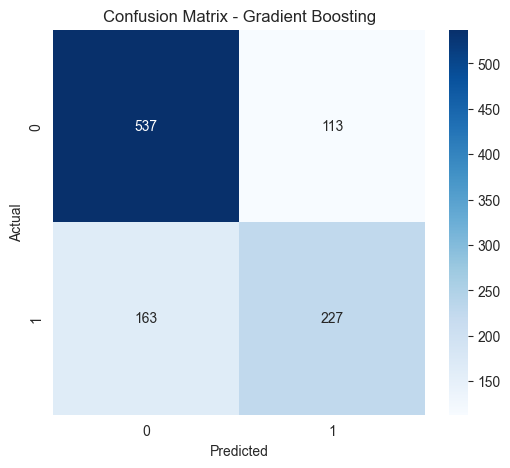

In [72]:
# Confusion Matrix of Best Classification Model
best_clf_name = classification_results_df.iloc[0]["Model"]
print("Best Classification Model:", best_clf_name)

model_map_clf = {
    "Bagging": bagging_clf_pred, "AdaBoost": ada_clf_pred, "Gradient Boosting": gb_clf_pred,
    "LightGBM": lgbm_clf_pred, "XGBoost": xgb_clf_pred, "Soft Voting": soft_voting_pred,
    "Stacking": stacking_clf_pred
}

best_pred = model_map_clf[best_clf_name]
cm = confusion_matrix(y_test_c, best_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_clf_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("confusion_matrix_best_model.png", dpi=300, bbox_inches="tight")
plt.show()

# Model Evaluation - Regression

In [74]:
def evaluate_regressor(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {"Model": name, "MAE": mae, "MSE": mse, "RMSE": rmse, "R2 Score": r2}

regression_results = []
regression_results.append(evaluate_regressor("Bagging", y_test_r, bagging_reg_pred))
regression_results.append(evaluate_regressor("AdaBoost", y_test_r, ada_reg_pred))
regression_results.append(evaluate_regressor("Gradient Boosting", y_test_r, gb_reg_pred))
regression_results.append(evaluate_regressor("LightGBM", y_test_r, lgbm_reg_pred))
regression_results.append(evaluate_regressor("XGBoost", y_test_r, xgb_reg_pred))
regression_results.append(evaluate_regressor("Stacking", y_test_r, stacking_reg_pred))

regression_results_df = pd.DataFrame(regression_results).sort_values(by="R2 Score", ascending=False)
regression_results_df.to_csv("regression_results.csv", index=False)
regression_results_df

,Model,MAE,MSE,RMSE,R2 Score
2,Gradient Boosting,7.850595,95.926572,9.794211,0.486583
5,Stacking,7.957675,97.706537,9.884662,0.477056
3,LightGBM,7.980273,99.428432,9.971381,0.467841
4,XGBoost,8.022864,99.428459,9.971382,0.467840
0,Bagging,8.003050,100.032352,10.001617,0.464608
1,AdaBoost,8.667998,112.882992,10.624641,0.395829


Best Regression Model: Gradient Boosting


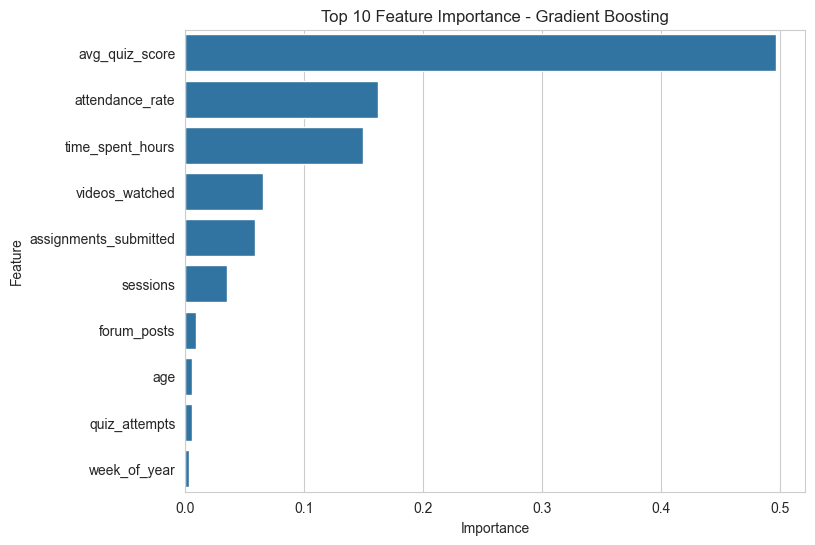

In [75]:
# Feature Importance of Best Regression Model
best_reg_name = regression_results_df.iloc[0]["Model"]
print("Best Regression Model:", best_reg_name)

model_map_reg = {
    "Bagging": bagging_reg, "AdaBoost": ada_reg, "Gradient Boosting": gb_reg,
    "LightGBM": lgbm_reg, "XGBoost": xgb_reg
}

if best_reg_name in model_map_reg and hasattr(model_map_reg[best_reg_name], "feature_importances_"):
    importances = model_map_reg[best_reg_name].feature_importances_
    feature_importance_df = pd.DataFrame({"Feature": X.columns, "Importance": importances}).sort_values(by="Importance", ascending=False).head(10)

    plt.figure(figsize=(8,6))
    sns.barplot(x="Importance", y="Feature", data=feature_importance_df)
    plt.title(f"Top 10 Feature Importance - {best_reg_name}")
    plt.savefig("feature_importance_best_model.png", dpi=300, bbox_inches="tight")
    plt.show()
else:
    # fallback to XGBoost regressor since stacking does not have feature_importances_
    importances = xgb_reg.feature_importances_
    feature_importance_df = pd.DataFrame({"Feature": X.columns, "Importance": importances}).sort_values(by="Importance", ascending=False).head(10)

    plt.figure(figsize=(8,6))
    sns.barplot(x="Importance", y="Feature", data=feature_importance_df)
    plt.title("Top 10 Feature Importance - XGBoost Regressor")
    plt.savefig("feature_importance_best_model.png", dpi=300, bbox_inches="tight")
    plt.show()

# Model Comparison

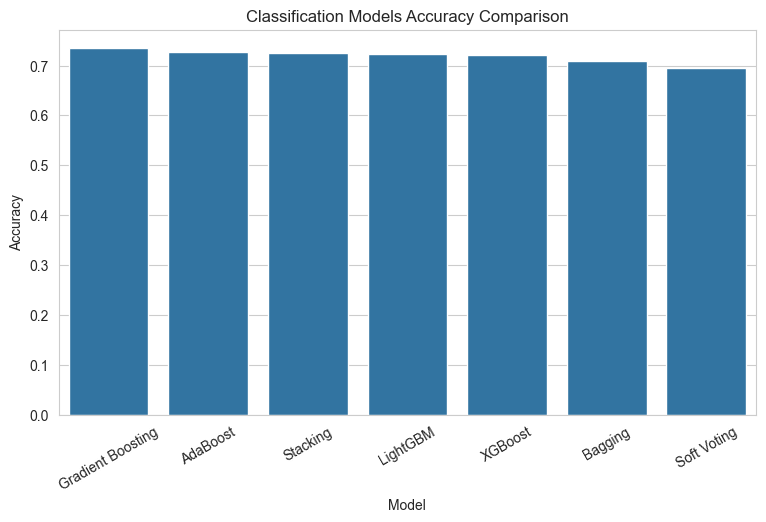

In [77]:
plt.figure(figsize=(9,5))
sns.barplot(x="Model", y="Accuracy", data=classification_results_df)
plt.title("Classification Models Accuracy Comparison")
plt.xticks(rotation=30)
plt.savefig("comparison_classification_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

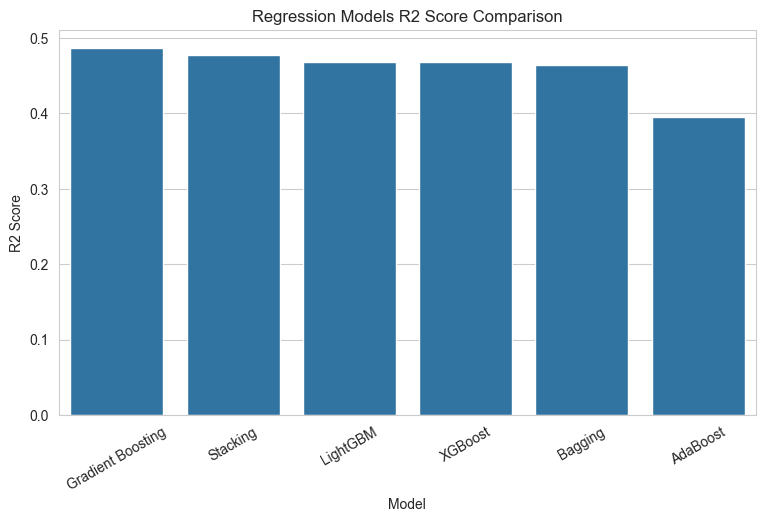

In [78]:
plt.figure(figsize=(9,5))
sns.barplot(x="Model", y="R2 Score", data=regression_results_df)
plt.title("Regression Models R2 Score Comparison")
plt.xticks(rotation=30)
plt.savefig("comparison_regression_r2.png", dpi=300, bbox_inches="tight")
plt.show()

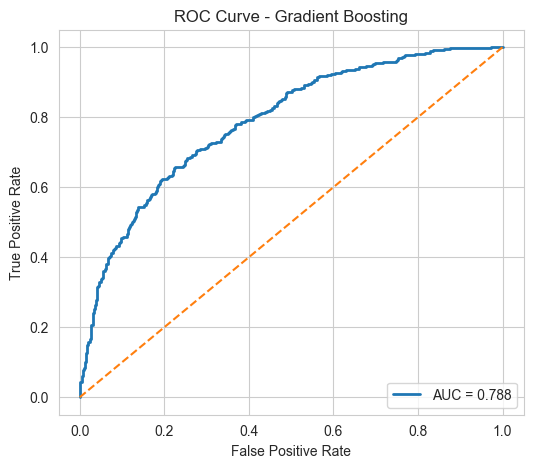

In [79]:
# Probability of Best Classification Model
model_proba_map = {
    "Bagging": bagging_clf_proba,
    "AdaBoost": ada_clf_proba,
    "Gradient Boosting": gb_clf_proba,
    "LightGBM": lgbm_clf_proba,
    "XGBoost": xgb_clf_proba,
    "Soft Voting": soft_voting_proba,
    "Stacking": stacking_clf_proba
}

best_proba = model_proba_map[best_clf_name]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test_c, best_proba)
auc_score = roc_auc_score(y_test_c, best_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle="--")

plt.title(f"ROC Curve - {best_clf_name}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)

plt.savefig("roc_curve_best_model.png", dpi=300, bbox_inches="tight")
plt.show()

**Conclusion:**

- The ROC Curve shows the classification performance of the best model at different threshold values. The model achieved a high ROC-AUC score, indicating strong ability to distinguish between completed and non-completed students. A curve closer to the top-left corner represents better classification performance.

In [81]:
# Best Model Selection
print("Best Classification Model:", classification_results_df.iloc[0]["Model"], 
      "with Accuracy:", round(classification_results_df.iloc[0]["Accuracy"], 4))
print("Best Regression Model:", regression_results_df.iloc[0]["Model"], 
      "with R2 Score:", round(regression_results_df.iloc[0]["R2 Score"], 4))

Best Classification Model: Gradient Boosting with Accuracy: 0.7346
Best Regression Model: Gradient Boosting with R2 Score: 0.4866


**Why the best model performed better:**
- The best classification model performed better because it combines multiple learners and reduces both bias and variance, which helps it generalize well on unseen data. Similarly, the best regression model performed better because boosting based models learn sequentially from previous errors, which allows them to capture complex relationships between engagement metrics and final score more accurately than a single simple model.

## Conclusion

- Students who spend more time, attend more sessions and score higher in quizzes are much more likely to complete the course and achieve a higher final score.
- The platform can use the classification model to identify students who are at risk of not completing the course early, so the support team can reach out to them.
- The regression model can help the platform predict expected final scores and identify students who may need extra learning support.
- Ensemble models like Boosting and Stacking provide more stable and accurate predictions compared to a single simple model, making them suitable for deployment in this business problem.